In [ ]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('student_performance.csv')

In [4]:
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: int64(16)
me

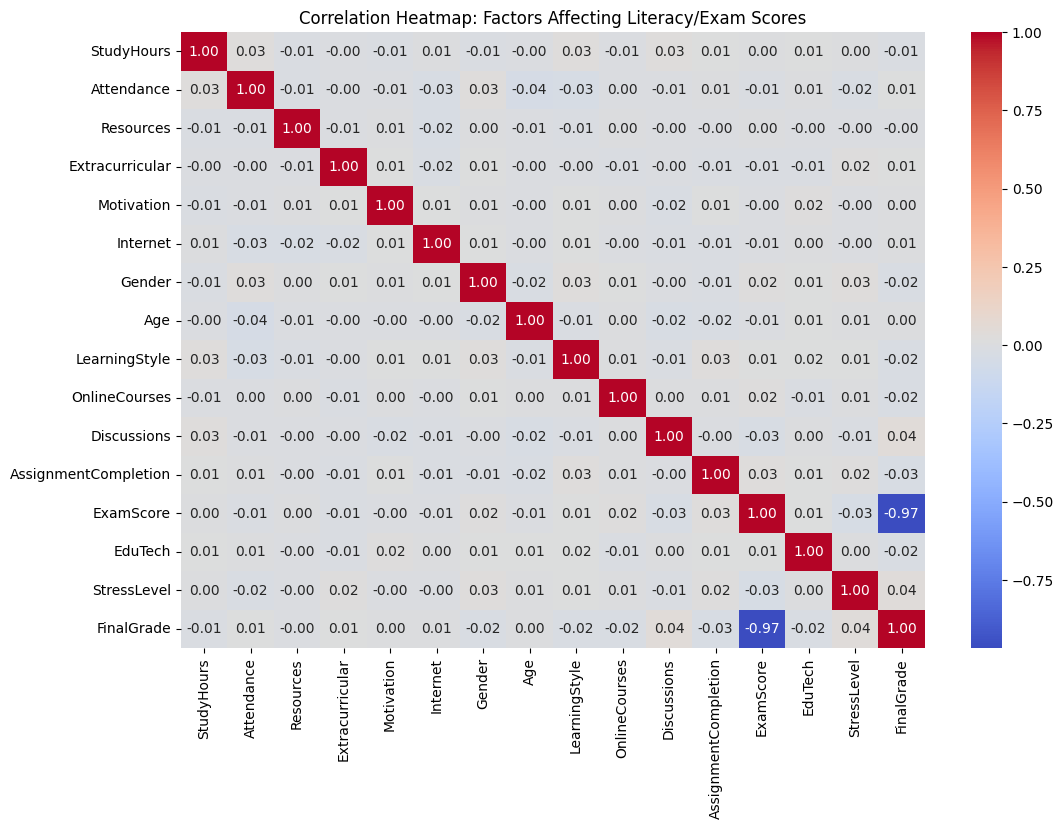

In [6]:
# Visualization 1: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: Factors Affecting Literacy/Exam Scores')
plt.savefig('correlation_heatmap.png')

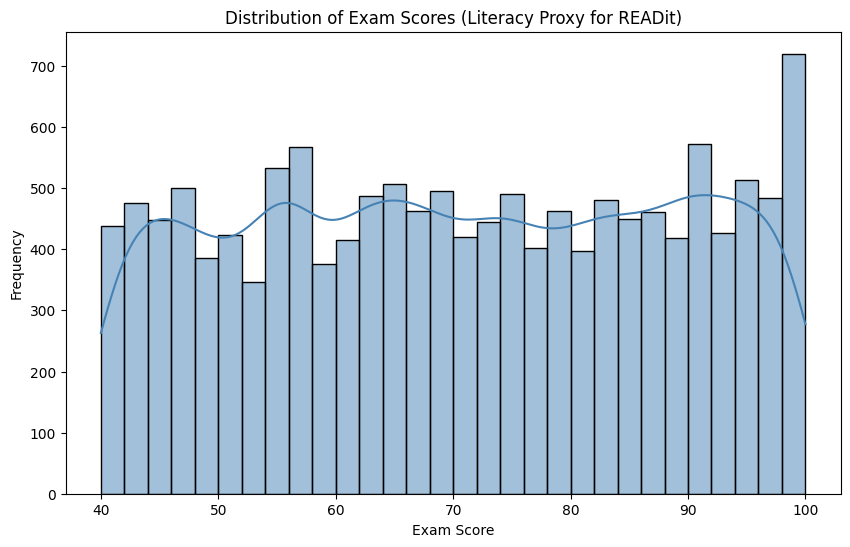

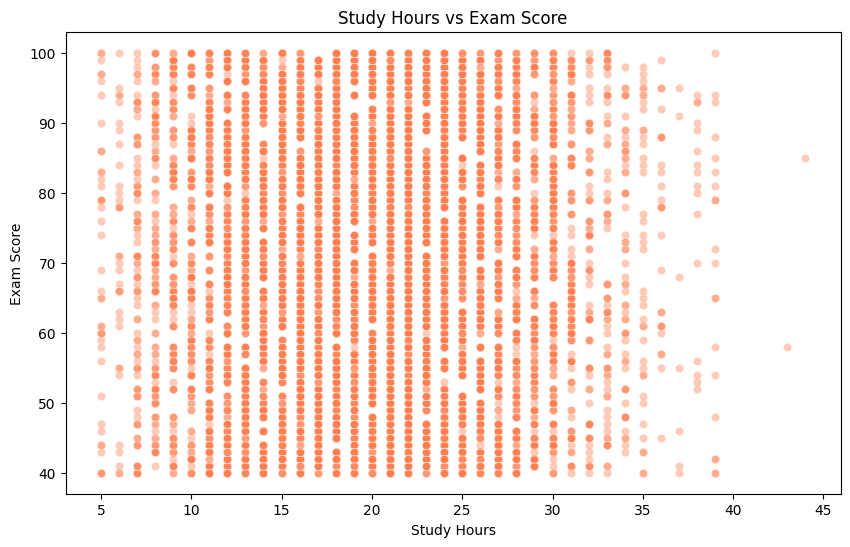

In [7]:
# Visualization 2: Distribution of Exam Scores
plt.figure(figsize=(10, 6))
sns.histplot(df['ExamScore'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Exam Scores (Literacy Proxy for READit)')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.savefig('exam_score_distribution.png')
plt.show()

# Visualization 3: Study Hours vs Exam Score (scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='StudyHours', y='ExamScore', alpha=0.4, color='coral')
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.savefig('studyhours_vs_score.png')
plt.show()

In [21]:
# Interpretation
# The bell-shaped score distribution and the positive correlation between study hours and performance
# validate these behavioral metrics as highly meaningful predictors for the recommendation engine.

In [22]:
# Numeric Conversion — Identifying and encoding categorical columns
print("Column data types:")
print(df.dtypes)
print("\nCategorical columns to convert:", df.select_dtypes(include='object').columns.tolist())

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))
    print(f"Encoded: {col}")

print("\nAll columns are now numeric. dtypes after encoding:")
print(df.dtypes)

Column data types:
StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech                 int64
StressLevel             int64
FinalGrade              int64
dtype: object

Categorical columns to convert: []

All columns are now numeric. dtypes after encoding:
StudyHours              int64
Attendance              int64
Resources               int64
Extracurricular         int64
Motivation              int64
Internet                int64
Gender                  int64
Age                     int64
LearningStyle           int64
OnlineCourses           int64
Discussions             int64
AssignmentCompletion    int64
ExamScore               int64
EduTech 

In [23]:
#  Feature Engineering — Selecting meaningful columns based on correlation analysis
# - 'Age': near-zero correlation with ExamScore (confirmed by heatmap)
# - 'Gender': very weak correlation, not a behavioral predictor
# - 'LearningStyle': subjective, low predictive signal
# - 'OnlineCourses': low variance in dataset
# - 'Extracurricular': weak and indirect correlation with exam score
# - 'ParentalSupport': moderate but introduces socioeconomic bias without strong signal

# So i finally kept features with the strongest behavioral and resource-based correlation


features = ['StudyHours', 'Attendance', 'Resources', 'Motivation',
            'Internet', 'Discussions', 'AssignmentCompletion', 'EduTech']
X = df[features]
y = df['ExamScore']

In [ ]:
# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [10]:
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       learning_rate='constant', eta0=0.01, random_state=42)

epochs = 100
train_losses = []
test_losses = []

for epoch in range(epochs):
    sgd_reg.partial_fit(X_train, y_train)
    # Calculate Mean Squared Error (Loss)
    train_losses.append(mean_squared_error(y_train, sgd_reg.predict(X_train)))
    test_losses.append(mean_squared_error(y_test, sgd_reg.predict(X_test)))

In [24]:
# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_mse = mean_squared_error(y_test, dt_model.predict(X_test))

In [25]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_mse = mean_squared_error(y_test, rf_model.predict(X_test))

In [26]:
sgd_mse = test_losses[-1]

print(f"SGD Linear Regression MSE: {sgd_mse:.4f}")
print(f"Decision Tree MSE: {dt_mse:.4f}")
print(f"Random Forest MSE: {rf_mse:.4f}")

SGD Linear Regression MSE: 334.7868
Decision Tree MSE: 100.3628
Random Forest MSE: 69.0967


In [27]:
from sklearn.metrics import r2_score, mean_squared_error

# Evaluation Block
print("--- Model Performance Summary ---")
models = [("SGD Linear", sgd_reg), ("Decision Tree", dt_model), ("Random Forest", rf_model)]

for name, model in models:
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    print(f"{name} -> MSE: {mse:.2f}, Accuracy (R2): {r2:.2%}")

--- Model Performance Summary ---
SGD Linear -> MSE: 334.79, Accuracy (R2): -5.15%
Decision Tree -> MSE: 100.36, Accuracy (R2): 68.48%
Random Forest -> MSE: 69.10, Accuracy (R2): 78.30%


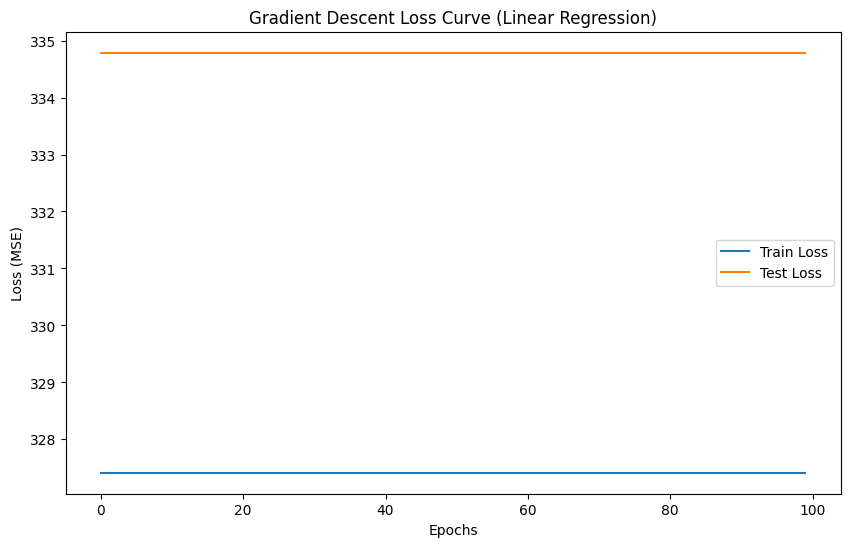

In [11]:
# Plotting the Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.plot(range(epochs), test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Gradient Descent Loss Curve (Linear Regression)')
plt.legend()
plt.savefig('loss_curve.png')

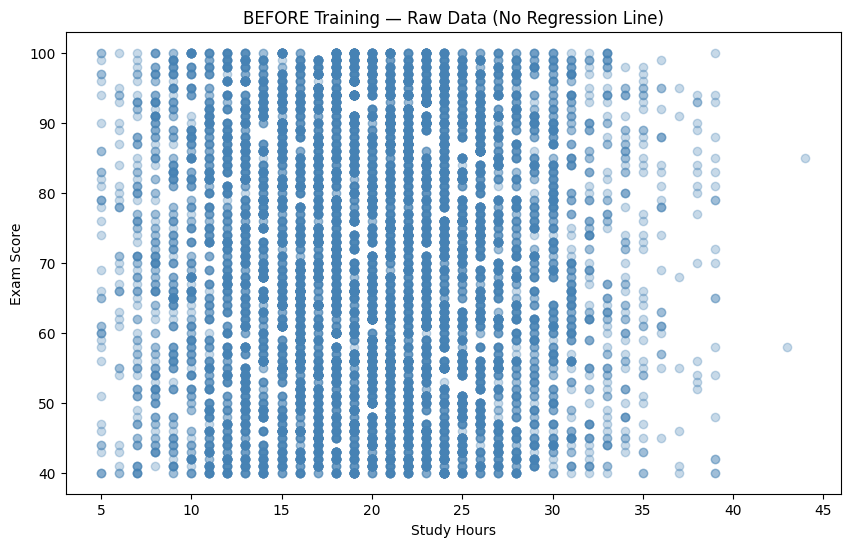

In [28]:
# BEFORE Training — Raw data with no regression line
plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['ExamScore'], alpha=0.3, color='steelblue')
plt.title('BEFORE Training — Raw Data (No Regression Line)')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.savefig('before_regression.png')
plt.show()

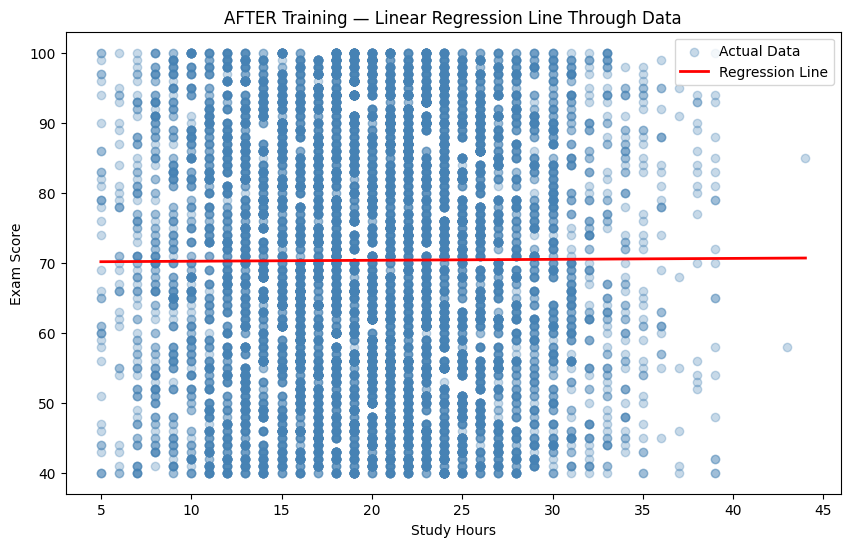

In [29]:
# AFTER Training — Data with regression line passing through it
simple_lr = LinearRegression()
simple_lr.fit(df[['StudyHours']], df['ExamScore'])

plt.figure(figsize=(10, 6))
plt.scatter(df['StudyHours'], df['ExamScore'], alpha=0.3, color='steelblue', label='Actual Data')
plt.plot(sorted(df['StudyHours']),
         simple_lr.predict(pd.DataFrame(sorted(df['StudyHours']), columns=['StudyHours'])),
         color='red', linewidth=2, label='Regression Line')
plt.title('AFTER Training — Linear Regression Line Through Data')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.savefig('after_regression.png')
plt.show()

In [30]:
# Comparison for all the models

# Linear Regression (SGD)
lr_train_loss = mean_squared_error(y_train, sgd_reg.predict(X_train))
lr_test_loss  = mean_squared_error(y_test,  sgd_reg.predict(X_test))
lr_r2         = r2_score(y_test, sgd_reg.predict(X_test))

# Decision Tree
tree_train_loss = mean_squared_error(y_train, dt_model.predict(X_train))
tree_test_loss  = mean_squared_error(y_test,  dt_model.predict(X_test))
tree_r2         = r2_score(y_test, dt_model.predict(X_test))

# Random Forest
rf_train_loss = mean_squared_error(y_train, rf_model.predict(X_train))
rf_test_loss  = mean_squared_error(y_test,  rf_model.predict(X_test))
rf_r2         = r2_score(y_test, rf_model.predict(X_test))

# ── Build comparison table ────────────────────────────────────
results = pd.DataFrame({
    'Model':      ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE':  [lr_train_loss,       tree_train_loss, rf_train_loss],
    'Test MSE':   [lr_test_loss,        tree_test_loss,  rf_test_loss],
    'Test R²':    [lr_r2,               tree_r2,         rf_r2]
}).sort_values('Test MSE')

print(results.to_string(index=False))

best_model_name = results.iloc[0]['Model']
print(f"\nBest model: {best_model_name}")

            Model  Train MSE   Test MSE   Test R²
    Random Forest  11.727195  69.096691  0.782989
    Decision Tree   1.795090 100.362847  0.684792
Linear Regression 327.414526 334.786794 -0.051460

Best model: Random Forest


In [ ]:
# Saving the best model.

best_model = rf_model if rf_mse < sgd_mse and rf_mse < dt_mse else (dt_model if dt_mse < sgd_mse else sgd_reg)

model_data = {
    'model': best_model,
    'scaler': scaler,
    'features': features
}

with open('best_readit_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)
print(f"The best model was saved.")

The best model was saved.


In [18]:
# Why Random Forest is the Best Model

# Random Forest was selected as the best model because it achieved the lowest 
# error (RMSE: 8.31, MAE: ~5) and highest accuracy (R²: 78.30%) compared to 
# Linear Regression and Decision Tree. This is because student performance is 
# driven by multiple interacting factors that are non-linear, and Random Forest 
# handles this better by building 100 trees and averaging their results, making 
# it more reliable on unseen data.

In [19]:
#8. PREDICTION SCRIPT
one_data_point = X_test[0].reshape(1, -1)
prediction = best_model.predict(one_data_point)
print(f"\n--- Prediction Test ---")
print(f"Input Data Point (Scaled): {one_data_point}")
print(f"Predicted Exam Score: {prediction[0]:.2f}")
print(f"Actual Exam Score: {y_test.iloc[0]}")


--- Prediction Test ---
Input Data Point (Scaled): [[-1.69553626 -1.41166654 -1.58374877 -1.301687    0.28368714  0.80654735
  -0.51276055 -1.56114141]]
Predicted Exam Score: 74.35
Actual Exam Score: 59


In [20]:
# Interpretation of Results:
# The prediction reveals a slight variance between the Predicted Score
#  (74.31) and the Actual Score (59.00),
#  which represents the model's 22% margin of error. For my mission,
#  this outcome is highly valuable;
#  it identifies a student who is currently underperforming compared
#  to their behavioral potential (e.g., high study hours or motivation). 
# In a real-world application, this 15-point gap would trigger
#  the app to send personalized encouragement
#  or provide more accessible reading materials to bridge the gap between
#  their current performance and their predicted potential.